In [ ]:
import mne
import os

In [9]:
# 1. Dosya yolunu bir 'motor hareket' kaydıyla değiştir (Örn: R03)
data_path = '../physioNet_Dataset/S001/S001R03.edf' 
# 1. Veriyi ham formatta oku (Raw object)
# 'preload=True' veriyi doğrudan RAM'e yükler, işlemler daha hızlı olur.
raw = mne.io.read_raw_edf(data_path, preload=True)

# 2. Veri hakkında genel bilgileri görüntüle
# print(raw.info)

# 3. Kanalları ve örnekleme frekansını kontrol et
print(f"Kanallar: {raw.ch_names}")
print(f"Örnekleme Frekansı (sfreq): {raw.info['sfreq']} Hz")

Extracting EDF parameters from ../physioNet_Dataset/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Kanallar: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']
Örnekleme Frekansı (sfreq): 160.0 Hz


In [10]:
# 1. Kanal isimlerindeki noktaları temizle ve büyük harfe çevir
# Bu işlem 'Fc5.' gibi isimleri 'FC5' haline getirir, böylece standartla eşleşir.
mapping = {ch_name: ch_name.rstrip('.').upper() for ch_name in raw.ch_names}
raw.rename_channels(mapping)

# 2. Montage (elektrot yerleşimi) ayarla
try:
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')    
    print("Montage başarıyla ayarlandı.")
except ValueError as e:
    print(f"Hala eşleşmeyen kanallar var: {e}")
    # Eğer hala hata veriyorsa, eşleşmeyen kanalları bulup listeden çıkarabiliriz

Montage başarıyla ayarlandı.


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition

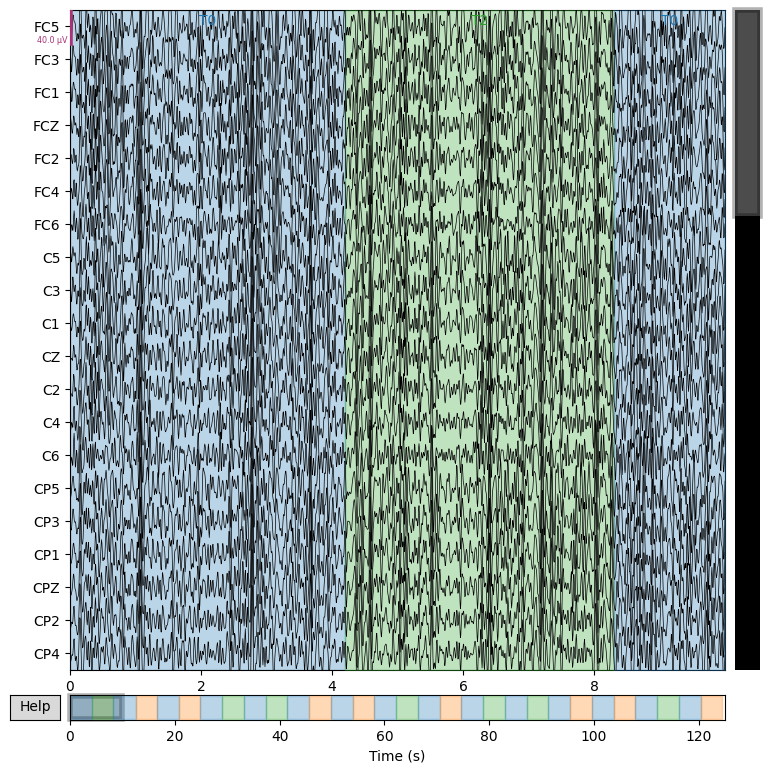

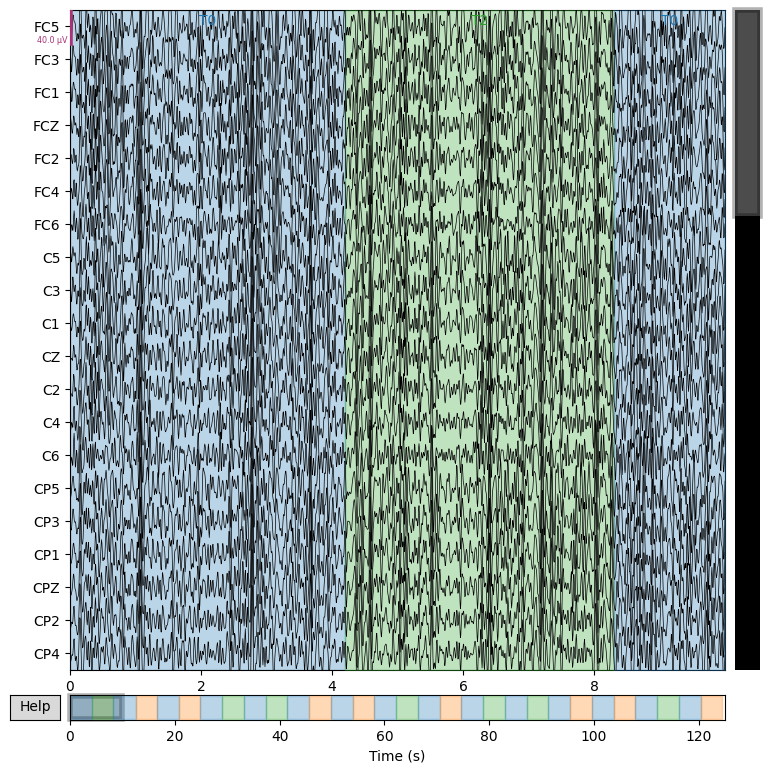

In [11]:
# Sadece EEG kanallarını seç (bazı kayıtlarda ekstra kanallar olabilir)
raw.pick_types(eeg=True)

# Bant Geçiren Filtre: 8-30 Hz (Motor hayal için en kritik bantlar)
raw.filter(l_freq=8.0, h_freq=30.0, fir_design='firwin')

# Çentik Filtre: 50 Hz şebeke gürültüsü için
raw.notch_filter(freqs=50)

# Sinyali görselleştirerek gürültülerin gidip gitmediğini kontrol edebilirsin
raw.plot()

In [12]:
events, event_id = mne.events_from_annotations(raw)
print("Verideki Etiketler (Event IDs):", event_id)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Verideki Etiketler (Event IDs): {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


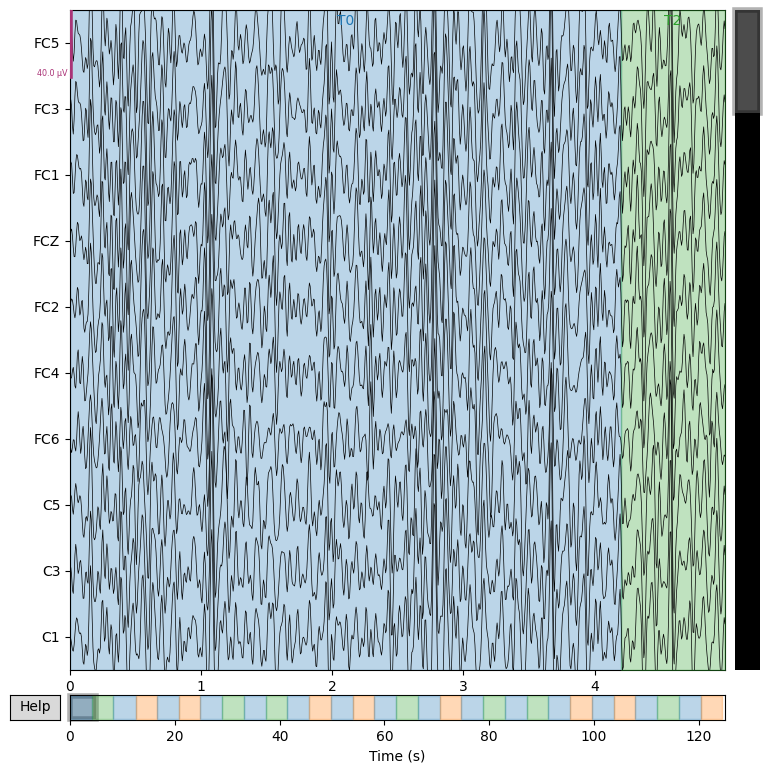

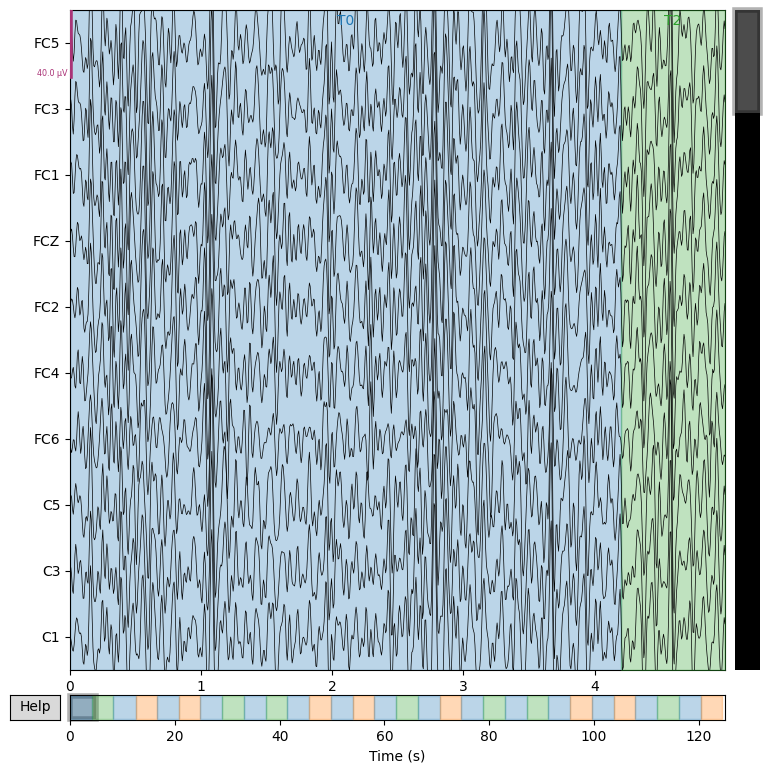

In [ ]:
# 1. Başlangıçtaki ham veriyi (filtresiz) göster
# (Not: raw_orig değişkenine ilk okuduğun halini kopyaladığını varsayıyorum, 
# yoksa tekrar okuyup görselleştirebilirsin)
raw.plot(duration=5, n_channels=10, title="Ham EEG Sinyali (Filtresiz)")

# 2. Şu anki filtrelenmiş veriyi göster
raw.plot(duration=5, n_channels=10, title="Ön İşlemi Yapılmış EEG Sinyali (8-30 Hz)")